In [17]:
# =====================================================
# 3. CMM 이미지 분류 실습
# 예제 데이터 : Fashion MNIST
# 목표 :
# - CNN 기반 이미지 분류
# - 학습 결과 저장
# - 저장된 모델결과 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화
# =====================================================

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.externals.array_api_compat.cupy import reshape
from torch.backends.mkl import verbose


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,auc
from sklearn.datasets import load_digits, load_breast_cancer
import joblib # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

# keras 모델 저장 및 로드 기능 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, Flatten, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [20]:
# ======================================
# 1 데이터 가져오기
# ======================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() # fashion mnist 데이터 가져오기

# 클래스 이름 정의
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandals',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# 데이터 shape 확인
print('X_train shape : ',X_train.shape)
print('X_test shape : ',X_test.shape)


X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [21]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [22]:
# ======================================
# 2. 데이터 정규화
# ======================================

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0 # 0 ~ 255 사이에서 크게 널뛰던 픽셀 값들이 0.0 ~ 1.0 사이의 값이 됨.
X_test = X_test / 255.0

# CNN 입력 형태에 맞게 채널 차원을 Reshape
X_train = X_train.reshape(-1, 28,28, 1)
X_test = X_test.reshape(-1, 28,28, 1)

In [23]:
# ======================================
# 3. 모델 정의
# ======================================

# 순차형 신경망 생성
model = Sequential()

# 첫 번째 합성곱 층을 추가
model.add(
    Conv2D(32, kernel_size=(3, 3),
           activation='relu',
           input_shape=(28, 28, 1)))

# 풀링 층 추가
model.add(MaxPooling2D(pool_size=(2, 2)))

# 두 번째 합성곱 층을 추가
model.add(Conv2D(64, (3, 3), activation='relu'))

# 두 번째 풀링 추가
model.add(MaxPooling2D(pool_size=(2, 2)))

# 1차원 벡터로 펼침
model.add(Flatten())
model.add(Dense(128, activation='relu'))

#드롭아웃 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# ======================================
# 4. 모델 컴파일
# ======================================

# 모델 컴파일 설정
model.compile(
    optimizer= "adam",
    # loss = "categorical_crossentropy",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
# ======================================
# 5. 모델 학습
# ======================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs = 20,
    batch_size = 64,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7966 - loss: 0.5605 - val_accuracy: 0.8687 - val_loss: 0.3719
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8669 - loss: 0.3674 - val_accuracy: 0.8808 - val_loss: 0.3221
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8844 - loss: 0.3176 - val_accuracy: 0.8898 - val_loss: 0.2988
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8957 - loss: 0.2868 - val_accuracy: 0.8954 - val_loss: 0.2862
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9027 - loss: 0.2637 - val_accuracy: 0.8978 - val_loss: 0.2769
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9109 - loss: 0.2422 - val_accuracy: 0.9052 - val_loss: 0.2672
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9168 - loss: 0.2254 - val_accuracy: 0.9030 - val_loss: 0.2617
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9222 - loss: 0.2095 - val_

In [28]:
# ======================================
# 6. 성능 평가
# ======================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

#결과 출력
print("테스트 손실 : ",test_loss )
print("테스트 정확도 : ",test_acc )

테스트 손실 :  0.2801697254180908
테스트 정확도 :  0.9003000259399414


In [30]:
# ======================================
# 7. 예측 확률 계산
# ======================================

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [31]:
# ======================================
# 8. 학습 결과 저장
# ======================================
# 모델 학습 결과 저장
model.save("./data/results/cnn_fashion_mnist.h5")

# 모델 학습 결과 읽어오기
loaded_model = tf.keras.models.load_model('./data/results/cnn_fashion_mnist.h5')

In [33]:
# ======================================
# 9. 신규 데이터 예측 / 분류
#======================================
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측 클래스 : {new_pred[i]} ({class_names[new_pred[i]]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1번 이미지 - 예측 클래스 : 9 (Ankle boot)
2번 이미지 - 예측 클래스 : 2 (Pullover)
3번 이미지 - 예측 클래스 : 1 (Trouser)
4번 이미지 - 예측 클래스 : 1 (Trouser)
5번 이미지 - 예측 클래스 : 6 (Shirt)


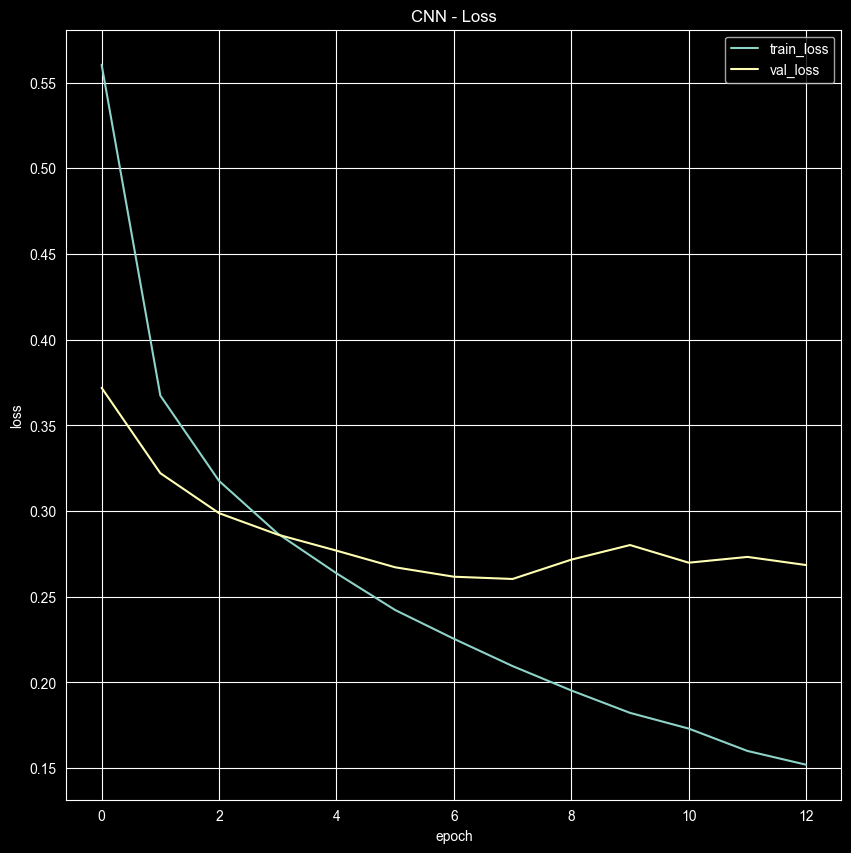

In [36]:
# ======================================
# 10. 결과 시각화
#======================================

# 학습 손실 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['loss'],label = 'train_loss' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

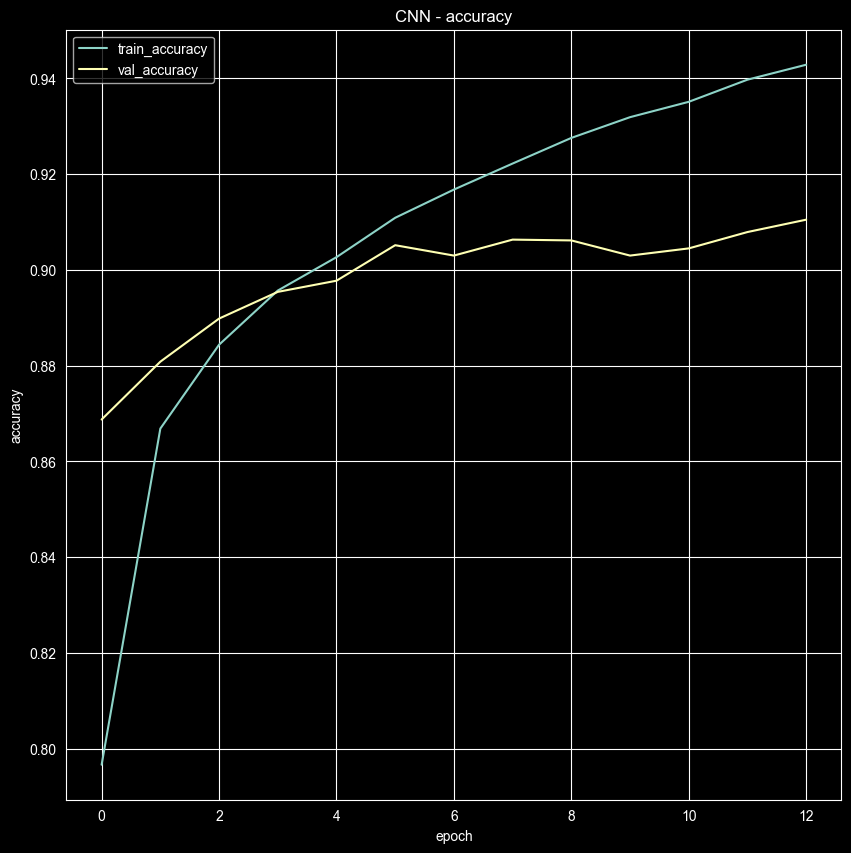

In [37]:
# 학습 정확도 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'],label = 'train_accuracy' )
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

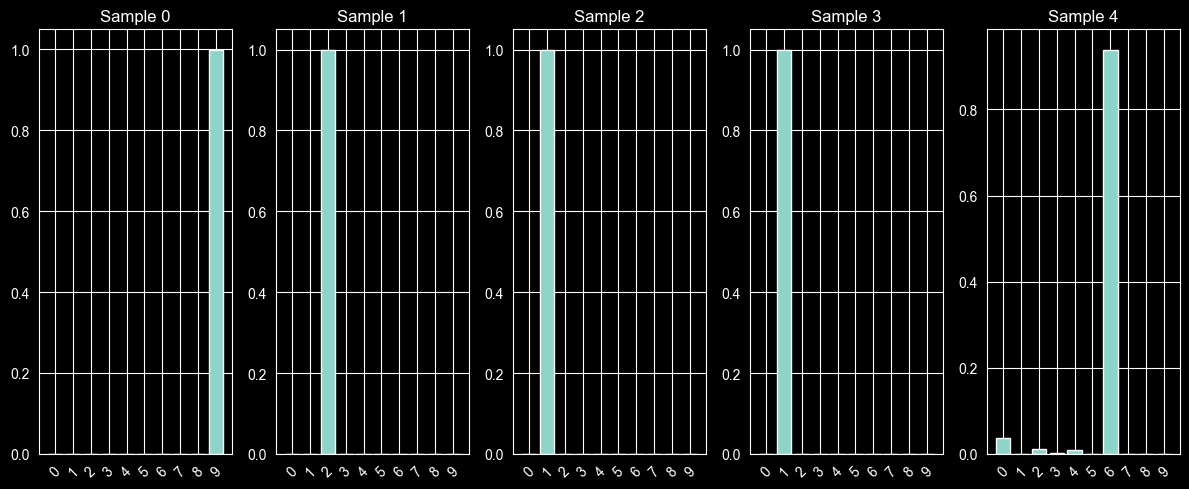

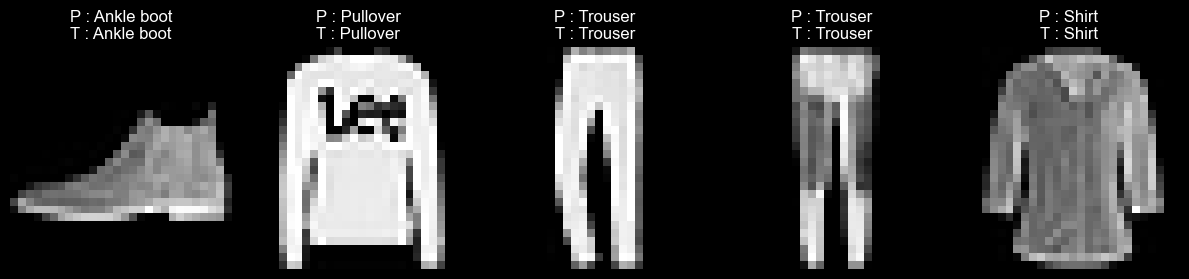

In [44]:
# 테스트 이미지와 예측 결과 시각화

plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i}")
    plt.xticks(range(10), rotation=45)

plt.tight_layout()
plt.show()


# 신규 이미지 5개에 대한 확률 분포 시각화
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P : {class_names[y_pred[i]]}\nT : {class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()